In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.decomposition import PCA

np.set_printoptions(precision=3, suppress=True)

RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)


In [2]:
#Illustration of broadcasting
a = np.asarray([[[1,2,3], [2,3,4], [2,3,4]]])
b = np.asarray([[[4,5,6]]])
print(a.shape, b.shape)
a[:,None,:]-b[None,:,:]

(1, 3, 3) (1, 1, 3)


array([[[[-3, -3, -3],
         [-2, -2, -2],
         [-2, -2, -2]]]])

### KNN classifier

In [3]:
class KNNClassifier:
    def __init__(self, k=1, distance_weighted=False, tau=1.0):
        self.k = k
        self.distance_weighted = distance_weighted
        self.tau = tau

    def fit(self, X, y):
        #KNN is memory-based: training ~ storing data samples
        self.X_train_ = np.asarray(X, dtype=float)
        self.y_train_ = np.asarray(y)
        self.classes_ =  np.unique(y)
        return self

    def _distances(self, X):
        #pairwise euclidean distances:
        # test shape (M,D), train shape (N,D)
        # output shape (M,N) i.e. distances from each training data
        X = np.asarray(X, dtype=float)
        diffs = X[:,None,:] - self.X_train_[None, :, :]
        return np.sqrt(np.sum(diffs**2, axis=2))

    def predict(self, X):
        dists = self._distances(X)

        nn_idx = np.argsort(dists, axis=1)[:,:self.k]

        preds = []


        for row, neighbours in enumerate(nn_idx):
            neighbour_labels = self.y_train_[neighbours]
            neighbour_dists = dists[row, neighbours]

            if not self.distance_weighted:
                # classification through majority
                counts = np.array([
                    np.sum(neighbour_labels == cls)
                    for cls in self.classes_
                ])
                preds.append(self.classes_[np.argmax(counts)]) # mode

            else:
                # exponential weightage
                weights = np.exp(-neighbour_dists / self.tau)

                class_scores = np.array(
                    [
                        weights[neighbour_labels == cls].sum()
                        for cls in self.classes_
                    ]
                )
                preds.append(self.classes_[np.argmax(class_scores)])

        return np.array(preds)

In [4]:
X_moons, y_moons = make_moons(
    n_samples=220,
    noise=0.22,
    random_state=RANDOM_STATE
) # toy dataset to visualize clustering

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.35,
    stratify=y_moons,
    random_state=RANDOM_STATE
)

knn1 = KNNClassifier(k=1).fit(X_m_train, y_m_train)

print("1-NN training accuracy: ", accuracy_score(y_m_train, knn1.predict(X_m_train)))
print("1-NN test accuracy: ", accuracy_score(y_m_test, knn1.predict(X_m_test)))

1-NN training accuracy:  1.0
1-NN test accuracy:  0.8961038961038961


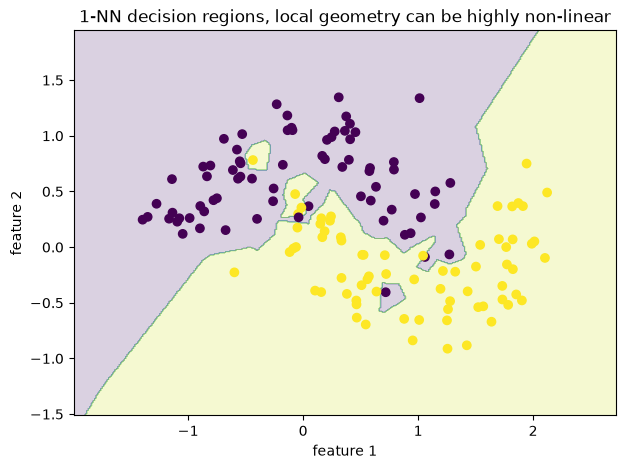

In [5]:
def plot_classifier_regions(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:,0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    pred = model.predict(grid).reshape(xx.shape)
    plt.figure(figsize=(7,5))
    plt.contourf(xx,yy,pred,alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.title(title)
    plt.show()

plot_classifier_regions(
    knn1,
    X_m_train,
    y_m_train,
    "1-NN decision regions, local geometry can be highly non-linear"
)


In [6]:
#validation for optimal k

k_values = [1,3,5,11,25,35,51]

knn_results = []

for k in k_values:
    model = KNNClassifier(k=k).fit(X_m_train, y_m_train)

    train_acc = accuracy_score(y_m_train, model.predict(X_m_train))
    test_acc = accuracy_score(y_m_test, model.predict(X_m_test))

    knn_results.append((k, train_acc, test_acc))

for k, train_acc, test_acc in knn_results:
    print(
        f"K={k:<3}"
        f" train={train_acc:.3f}"
        f" test={test_acc:.3f}"
    )

K=1   train=1.000 test=0.896
K=3   train=0.951 test=0.935
K=5   train=0.951 test=0.922
K=11  train=0.951 test=0.909
K=25  train=0.951 test=0.896
K=35  train=0.937 test=0.883
K=51  train=0.895 test=0.883


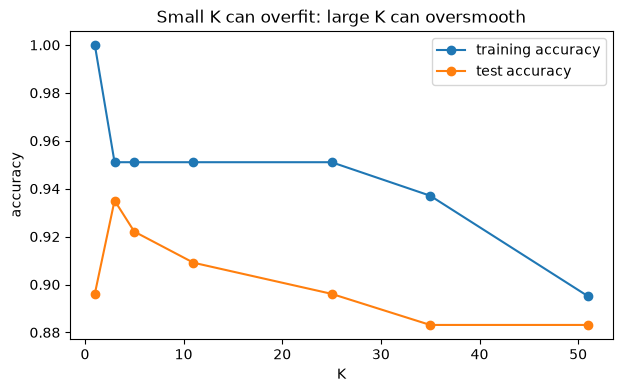

In [7]:
plt.figure(figsize=(7,4))
plt.plot(
    [result[0] for result in knn_results],
    [result[1] for result in knn_results],
    marker="o",
    label="training accuracy"
)
plt.plot(
    [result[0] for result in knn_results],
    [result[2] for result in knn_results],
    marker="o",
    label="test accuracy"
)
plt.xlabel("K")
plt.ylabel("accuracy")
plt.title("Small K can overfit: large K can oversmooth")
plt.legend()
plt.show()

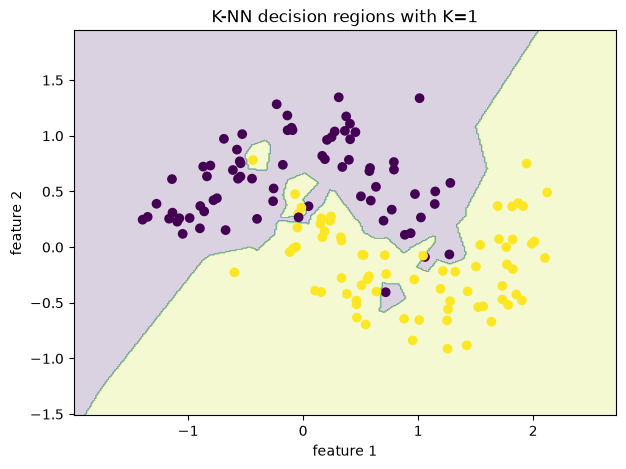

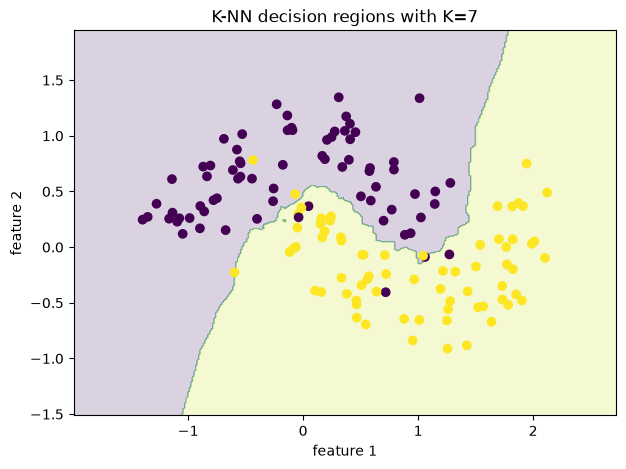

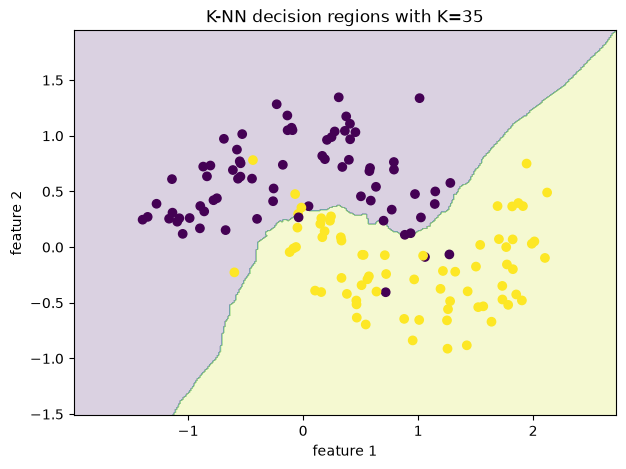

In [8]:
for k in [1,7,35]:
    model = KNNClassifier(k=k).fit(X_m_train,y_m_train)
    plot_classifier_regions(
        model,
        X_m_train,
        y_m_train,
        f"K-NN decision regions with K={k}"
    )

In [9]:
#cross validation for k

def cv_score_knn(X, y, k, n_splits=5):
    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    scores = []

    for train_idx, val_idx in splitter.split(X,y):
        model = KNNClassifier(k=k).fit(
            X[train_idx],
            y[train_idx]
        )

        pred = model.predict(X[val_idx])
        scores.append(accuracy_score(y[val_idx], pred))

    return np.mean(scores), np.std(scores)

candidate_k = [1, 3,5,7,11,15,21,31,41]

cv_knn = []

for k in candidate_k:
    mean_score, std_score = cv_score_knn(X_m_train, y_m_train, k)
    cv_knn.append([k, mean_score, std_score])

for k, mean_score, std_score in cv_knn:
    print(
        f"K={k:<3}"
        f" CV={mean_score:.3f}"
        f" +/- {std_score:.3f}"
    )
bestk = max(cv_knn, key=lambda row: row[1])[0]
print("Selected K = ", bestk)



K=1   CV=0.909 +/- 0.028
K=3   CV=0.923 +/- 0.025
K=5   CV=0.937 +/- 0.046
K=7   CV=0.944 +/- 0.035
K=11  CV=0.944 +/- 0.035
K=15  CV=0.930 +/- 0.049
K=21  CV=0.930 +/- 0.023
K=31  CV=0.909 +/- 0.049
K=41  CV=0.895 +/- 0.040
Selected K =  7


In [10]:
knn = KNNClassifier(k=bestk).fit(X_m_train, y_m_train)

test_accuracy = accuracy_score(
    y_m_test,
    knn.predict(X_m_test)
)

print("CV-selected K: ", bestk, "\nTest accuracy: ", test_accuracy)

CV-selected K:  7 
Test accuracy:  0.9090909090909091


### KNN Regressor

In [11]:
class KNNRegressor:
    def __init__(self, k=5, distance_weighted=False, tau=1.0):
        self.k = k
        self.distance_weighted = distance_weighted
        self.tau = tau

    def fit(self, X, y):
        self.X_train_ = np.asarray(X, dtype=float)
        self.y_train_ = np.asarray(y, dtype=float)
        return self

    def predict(self, X):
        X= np.asarray(X, dtype=float)

        diffs = X[:, None, :] - self.X_train_[None, :, :]
        dists = np.sqrt(np.sum(diffs**2, axis=2))

        nn_idx = np.argsort(dists, axis=1)[:, :self.k]

        preds = []

        for row, neighbours in enumerate(nn_idx):
            y_neighbours = self.y_train_[neighbours]
            d_neighbours = dists[row, neighbours]

            if not self.distance_weighted:
                preds.append(y_neighbours.mean())
            else:
                weights = np.exp(-d_neighbours / self.tau)
                weights = weights/ weights.sum()
                preds.append(np.sum(weights * y_neighbours))
        
        return np.array(preds)

In [12]:

#toy dataset for regression
x_reg = np.linspace(0,5,140)
y_true_curve = np.sin(1.3 * x_reg)
y_reg = y_true_curve + rng.normal(scale=0.18, size=len(x_reg))

X_reg = x_reg[:, None]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state= RANDOM_STATE
)
grid = np.linspace(0,5,400)[:, None]

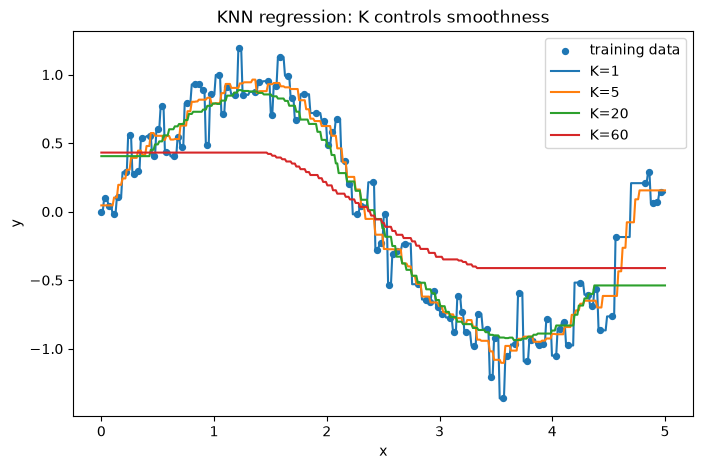

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(X_reg_train[:, 0], y_reg_train, s=18, label="training data")

for k in [1, 5, 20, 60]:
    model = KNNRegressor(k=k).fit(X_reg_train, y_reg_train)
    plt.plot(grid[:, 0], model.predict(grid), label=f"K={k}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("KNN regression: K controls smoothness")
plt.legend()
plt.show()


In [14]:
reg_k_values = [1, 3, 5, 9, 15, 25, 40, 60]

for k in reg_k_values:
    model = KNNRegressor(k=k).fit(
        X_reg_train,
        y_reg_train,
    )

    train_mse = mean_squared_error(
        y_reg_train,
        model.predict(X_reg_train),
    )

    test_mse = mean_squared_error(
        y_reg_test,
        model.predict(X_reg_test),
    )

    print(f"K={k:<3} train MSE={train_mse:.4f} test MSE={test_mse:.4f}")


K=1   train MSE=0.0000 test MSE=0.0677
K=3   train MSE=0.0156 test MSE=0.0350
K=5   train MSE=0.0194 test MSE=0.0338
K=9   train MSE=0.0286 test MSE=0.0294
K=15  train MSE=0.0435 test MSE=0.0389
K=25  train MSE=0.0696 test MSE=0.0700
K=40  train MSE=0.1085 test MSE=0.1040
K=60  train MSE=0.1757 test MSE=0.1679


In [15]:
X_demo = np.array([
    [0.0,0.0], #class 0
    [0.9,0.0], #class 1
    [0.0,0.9], #class 1
])
y_demo = np.array([0,1,1])

query = np.array([[0.15, 0.15]])

unweighted_knn = KNNClassifier(
    k=3, distance_weighted=False,
).fit(X_demo, y_demo)

weighted_knn = KNNClassifier(
    k=3, distance_weighted=True,
    tau=0.25
).fit(X_demo, y_demo)

print("Unweighted KNN prediction class: ", unweighted_knn.predict(query)[0])
print("Distance Weighted KNN prediction class: ", weighted_knn.predict(query)[0])

Unweighted KNN prediction class:  1
Distance Weighted KNN prediction class:  0


In [16]:
plain_reg = KNNRegressor(
    k=15,
    distance_weighted=False,
).fit(X_reg_train, y_reg_train)

weighted_reg = KNNRegressor(
    k=15,
    distance_weighted=True,
    tau=0.25,
).fit(X_reg_train, y_reg_train)

print(
    "Unweighted test MSE:",
    mean_squared_error(y_reg_test, plain_reg.predict(X_reg_test)),
)

print(
    "Weighted test MSE:",
    mean_squared_error(y_reg_test, weighted_reg.predict(X_reg_test)),
)


Unweighted test MSE: 0.038856173201126123
Weighted test MSE: 0.027944081814995452


In [17]:
def brute_force_query_time(N,D, repeats=5):
    data = rng.normal(size=(N,D))
    query = rng.normal(size=(1,D))

    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        dists = np.linalg.norm(data - query, axis=1)
        _ = np.argmin(dists)

        times.append(time.perf_counter() - start)

    return np.median(times)

sizes = [1000, 5000, 10000, 25000, 50000, 70000]
timings = [brute_force_query_time(N, D=64) for N in sizes]
for N, t in zip(sizes, timings):
    print(f"N={N:>6} median query time={1000*t:.3f} ms")

N=  1000 median query time=0.071 ms
N=  5000 median query time=0.293 ms
N= 10000 median query time=0.446 ms
N= 25000 median query time=1.474 ms
N= 50000 median query time=2.590 ms
N= 70000 median query time=3.207 ms


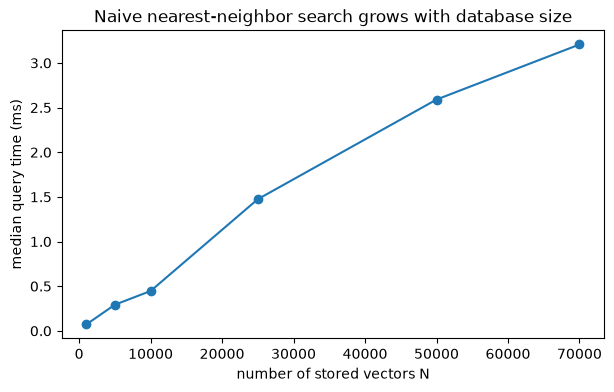

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(sizes, np.array(timings) * 1000, marker="o")
plt.xlabel("number of stored vectors N")
plt.ylabel("median query time (ms)")
plt.title("Naive nearest-neighbor search grows with database size")
plt.show()


In [19]:
## Applications of KNN

### Similarity Search and Retrieval
digits = load_digits()
database_vectors = digits.data.astype(float)
database_labels = digits.target
database_images = digits.images

def retrieve_nearest(query, database, k=6, exclude_index=None):
    dists = np.linalg.norm(database - query, axis=1)
    if exclude_index is not None:
        dists[exclude_index] = np.inf

    idx = np.argsort(dists)[:k]
    return idx, dists[idx]

query_idx = 137
query_vector = database_vectors[query_idx]

retrieved_idx, retrieved_dist = retrieve_nearest(
    query_vector,
    database_vectors,
    k=6,
    exclude_index=query_idx
)

print("query label: ", database_labels[query_idx])
print("retrieve label: ", database_labels[retrieved_idx])
print("distances: ", retrieved_dist)


query label:  7
retrieve label:  [7 7 7 7 7 7]
distances:  [17.146 18.547 18.708 19.053 19.799 19.875]


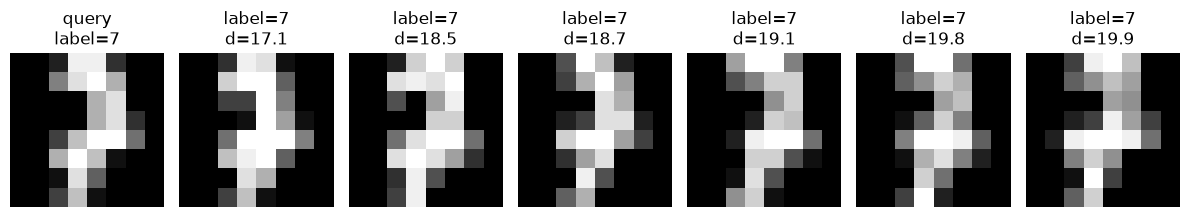

In [20]:
fig, axes = plt.subplots(1, 7, figsize=(12, 2.2))

axes[0].imshow(database_images[query_idx], cmap="gray")
axes[0].set_title(f"query\nlabel={database_labels[query_idx]}")
axes[0].axis("off")

for ax, idx, dist in zip(
    axes[1:],
    retrieved_idx,
    retrieved_dist,
):
    ax.imshow(database_images[idx], cmap="gray")
    ax.set_title(f"label={database_labels[idx]}\nd={dist:.1f}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [22]:
#PCA
#16D representation on all digit vectors for retrieval

pca16 = PCA(n_components=16, random_state=RANDOM_STATE)
digits_16d = pca16.fit_transform(database_vectors)

print("Original dimension: ", database_vectors.shape)
print("PCA dimensionality compressed: ", digits_16d.shape)


Original dimension:  (1797, 64)
PCA dimensionality compressed:  (1797, 16)


In [23]:
def timed_retrieval(database, queries, k=5):
    start = time.perf_counter()

    for q in queries:
        dists = np.linalg.norm(database - q, axis=1)
        _ = np.argpartition(dists, kth=k)[:k]

    return time.perf_counter() - start

query_ids = rng.choice(len(database_vectors), size=200, replace=False)

time_64d = timed_retrieval(
    database_vectors,
    database_vectors[query_ids]
)

time_16d = timed_retrieval(
    digits_16d,
    digits_16d[query_ids],
)

print(f"200 brute-force searches in 64-D: {time_64d:.4f} s")
print(f"200 brute-force searches in 16-D: {time_16d:.4f} s")

200 brute-force searches in 64-D: 0.0367 s
200 brute-force searches in 16-D: 0.0105 s


In [27]:
# Prune-first, and score fewer candidate approach for faster execution

from sklearn.cluster import KMeans

n_clusters = 20

coarse = KMeans(
    n_clusters=n_clusters,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_ids = coarse.fit_predict(digits_16d)

cluster_members = [
    np.where(cluster_ids == c)[0] for c in range(n_clusters)
]

def approximate_retrieve(query, k=5):
    centroid_dists = np.linalg.norm(
        coarse.cluster_centers_ - query,
        axis=1
    )
    best_cluster = np.argmin(centroid_dists)

    candidates = cluster_members[best_cluster]
    candidate_vectors = digits_16d[candidates]

    dists = np.linalg.norm(candidate_vectors - query, axis=1)

    k_functional = min(k, len(candidates))
    local_idx = np.argsort(dists)[:k_functional]

    return candidates[local_idx]

def exact_retrieve(query, k=5):
    dists = np.linalg.norm(digits_16d - query, axis=1)
    return np.argsort(dists)[:k]

In [28]:
query_ids = rng.choice(len(digits_16d), size=200, replace=False)
recalls = []

for qi in query_ids:
    q= digits_16d[qi]
    exact = set(exact_retrieve(q, k=5))
    approx = set(approximate_retrieve(q, k=5))
    recalls.append(len(exact & approx) /5)

print("Mean top-5 recall of crude approximate search: ", np.mean(recalls))

Mean top-5 recall of crude approximate search:  0.903


In [29]:

# Compare speed for many queries.
queries = digits_16d[query_ids]

start = time.perf_counter()
for q in queries:
    _ = exact_retrieve(q, k=5)
exact_time = time.perf_counter() - start

start = time.perf_counter()
for q in queries:
    _ = approximate_retrieve(q, k=5)
approx_time = time.perf_counter() - start

print(f"Exact brute-force search:   {exact_time:.4f} s")
print(f"Pruned approximate search:  {approx_time:.4f} s")

Exact brute-force search:   0.0393 s
Pruned approximate search:  0.0040 s
